In [1]:
import pandas as pd
from scipy.stats import spearmanr, pearsonr
from sklearn.metrics import mean_squared_error

In [2]:

# to function
def compare_predictions(file1, file2):
    # load
    df1 = pd.read_feather(file1)
    df2 = pd.read_feather(file2)

    # --- align rows ---
    # use identifiers that uniquely define a row
    merge_cols = ["variant_id", "gene_id", "tissue"]

    df_merged = df1.merge(
        df2,
        on=merge_cols,
        suffixes=("_pytorch", "_local")
    )

    # --- drop NaNs ---
    df_merged = df_merged.dropna(subset=["prediction_new_pytorch", "prediction_new_local"])

    # --- extract arrays ---
    y1 = df_merged["prediction_new_pytorch"].values
    y2 = df_merged["prediction_new_local"].values

    # --- metrics ---
    spearman = spearmanr(y1, y2)[0]
    pearson = pearsonr(y1, y2)[0]

    print(f"Rows compared: {len(df_merged)}")
    print(f"Spearman: {spearman:.4f}")
    print(f"Pearson:  {pearson:.4f}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 6))
    plt.scatter(y1, y2, s=5, alpha=0.5)
    # diagonal line (perfect agreement)
    min_val = min(y1.min(), y2.min())
    max_val = max(y1.max(), y2.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("PyTorch prediction")
    plt.ylabel("Local Alphagenome prediction")
    plt.title(f"Prediction comparison\nSpearman={spearman:.3f}")
    plt.tight_layout()
    plt.show()
    
    return df_merged

Rows compared: 4316
Spearman: 0.9684
Pearson:  0.9784


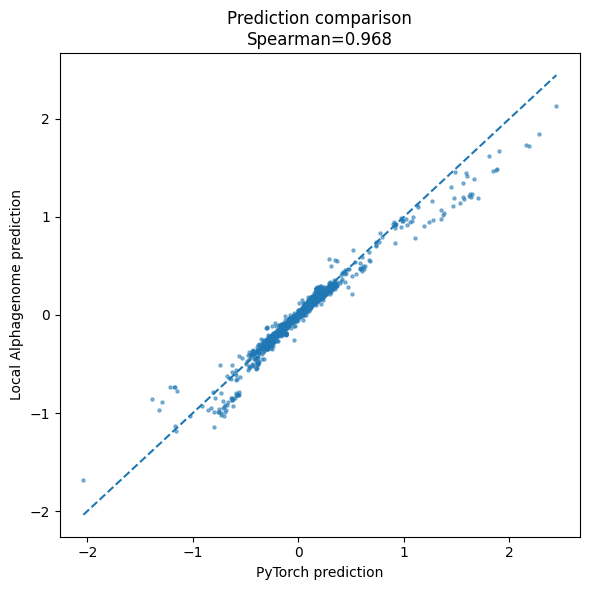

,variant_id,gene_id,tissue,prediction_pytorch,target_pytorch,variant_scorer_pytorch,output_type_pytorch,metric_calculator_pytorch,metric_name_pytorch,prediction_new_pytorch,prediction_local,target_local,variant_scorer_local,output_type_local,metric_calculator_local,metric_name_local,prediction_new_local
0,chr3_4491276_T_C_b38,ENSG00000231249.3,Adipose_Subcutaneous,0.101731,0.279811,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.093171,0.101731,0.279811,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.098881
1,chr3_8733693_G_T_b38,ENSG00000182533.7,Adipose_Subcutaneous,0.014747,0.567912,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.011369,0.014747,0.567912,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.000123
2,chr3_8963418_C_T_b38,ENSG00000070950.10,Adipose_Subcutaneous,-0.095976,-0.684296,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.136670,-0.095976,-0.684296,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.092913
3,chr3_9867065_G_C_b38,ENSG00000187288.12,Adipose_Subcutaneous,-0.000609,-0.130677,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.007301,-0.000609,-0.130677,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.002774
4,chr3_9903375_C_T_b38,ENSG00000163701.19,Adipose_Subcutaneous,-0.035684,-0.660048,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.019136,-0.035684,-0.660048,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.022656
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4684,chr19_36114973_G_T_b38,ENSG00000105254.12,Whole_Blood,0.052913,0.453086,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.058266,0.052913,0.453086,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.043509
4685,chr19_40750305_G_T_b38,ENSG00000188493.15,Whole_Blood,0.085684,1.149064,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.092220,0.085684,1.149064,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,0.095893
4686,chr19_40909182_G_A_b38,ENSG00000256612.9,Whole_Blood,-0.047596,1.018026,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.125596,-0.047596,1.018026,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.048136
4687,chr19_41586462_A_T_b38,ENSG00000007129.18,Whole_Blood,-0.670920,-0.802152,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.590636,-0.670920,-0.802152,gene_exons_contained_diff_mean;OutputType.RNA_...,RNA_SEQ,TissueAggregatedAnnDataCorrelations,None,-0.658398


In [3]:
# paths
file1 = "results/pytorch/coefficients_part1.feather"
file2 = "results/local/local_coefficients.feather"


compare_predictions(file1, file2)

Rows compared: 104
Spearman: 0.9877
Pearson:  0.9671


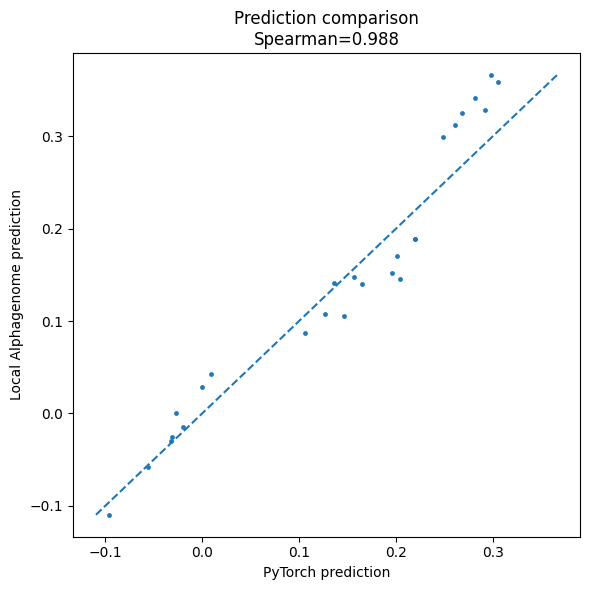

In [11]:
file_local_zeroshot = "results/local/local_zeroshot_part1.feather"
file_pytorch_zeroshot = "results/pytorch/zeroshot_test.feather"

compare_predictions(file_local_zeroshot, file_pytorch_zeroshot)

In [3]:
def compare_predictions_indel(file1, file2):
    # load
    df1 = pd.read_feather(file1)
    df2 = pd.read_feather(file2)
    
    # aggregate values among tracks and take the max
    df1 = (
        df1
        .groupby(["variant_id", "scored_interval", "ontology_curie", "gene_id", "gtex_tissue"], as_index=False)
        .agg({"raw_score": "max"})
    )

    df2 = (
        df2
        .groupby(["variant_id", "scored_interval", "ontology_curie", "gene_id", "gtex_tissue"], as_index=False)
        .agg({"raw_score": "max"})
    )
 
    # --- align rows ---
    # use identifiers that uniquely define a row
    merge_cols = ["variant_id", "gene_id", "ontology_curie", "gtex_tissue"]

    df_merged = df1.merge(
        df2,
        on=merge_cols,
        suffixes=("_pytorch", "_local")
    )

    # --- drop NaNs ---
    df_merged = df_merged.dropna(subset=["raw_score_pytorch", "raw_score_local"])

    # --- extract arrays ---
    y1 = df_merged["raw_score_pytorch"].values
    y2 = df_merged["raw_score_local"].values

    # --- metrics ---
    spearman = spearmanr(y1, y2)[0]
    pearson = pearsonr(y1, y2)[0]

    print(f"Rows compared: {len(df_merged)}")
    print(f"Spearman: {spearman:.4f}")
    print(f"Pearson:  {pearson:.4f}")

    import matplotlib.pyplot as plt
    plt.figure(figsize=(6, 6))
    plt.scatter(y1, y2, s=5, alpha=0.5)
    # diagonal line (perfect agreement)
    min_val = min(y1.min(), y2.min())
    max_val = max(y1.max(), y2.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    plt.xlabel("PyTorch prediction")
    plt.ylabel("Local Alphagenome prediction")
    plt.title(f"Prediction comparison\nSpearman={spearman:.3f}")
    plt.tight_layout()
    plt.show()
    
    return df_merged

In [8]:
file_pytorch_deletion = "results/indel_compare/pytorch_deletions.feather"
file_pytorch_insertion = "results/indel_compare/pytorch_insertions.feather"
file_local_deletion = "results/indel_compare/local_deletions.feather"
file_local_insertion = "results/indel_compare/local_insertions.feather"

Rows compared: 36072
Spearman: 0.7637
Pearson:  0.6449


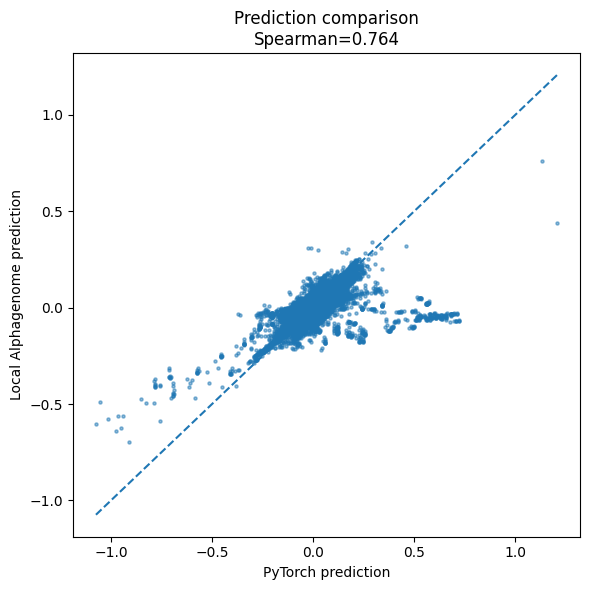

In [7]:


df = compare_predictions_indel(file_pytorch_insertion, file_local_insertion)

Rows compared: 29646
Spearman: 0.2812
Pearson:  0.3663


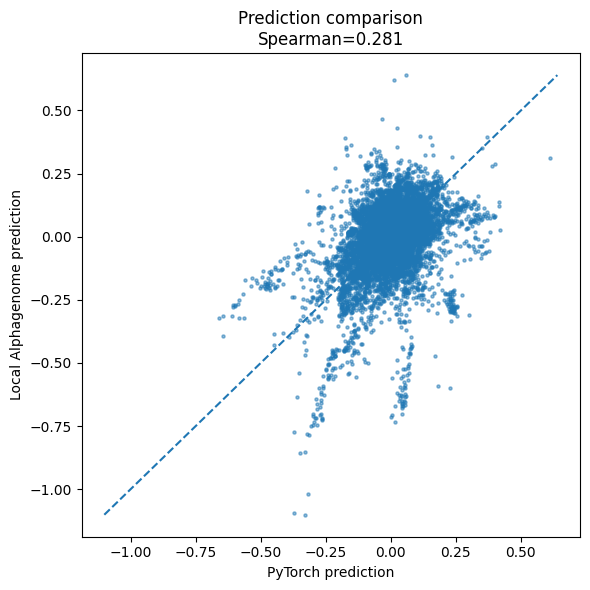

In [9]:
df = compare_predictions_indel(file_local_deletion, file_pytorch_deletion)

Rows compared: 65718
Spearman: 0.5305
Pearson:  0.4949


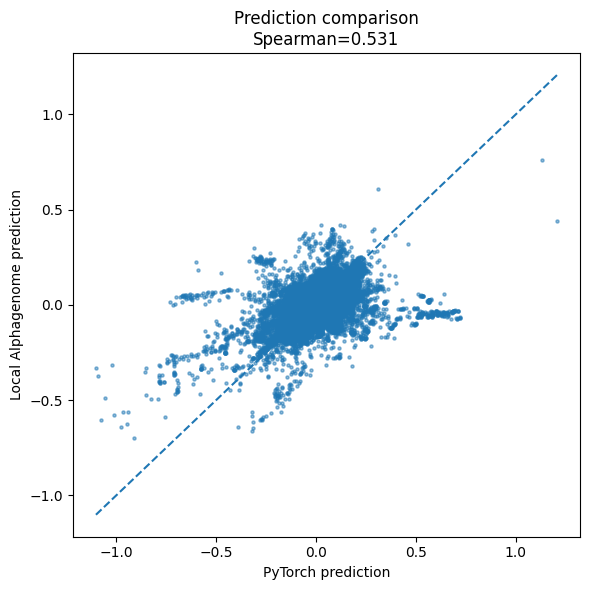

In [10]:
# indels

df_pytorch_deletion = pd.read_feather(file_pytorch_deletion)
df_pytorch_insertion = pd.read_feather(file_pytorch_insertion)
df_local_deletion = pd.read_feather(file_local_deletion)
df_local_insertion = pd.read_feather(file_local_insertion)

df1 = pd.concat([df_pytorch_deletion, df_pytorch_insertion])
df2 = pd.concat([df_local_deletion, df_local_insertion])

# aggregate values among tracks and take the max
df1 = (
    df1
    .groupby(["variant_id", "scored_interval", "ontology_curie", "gene_id", "gtex_tissue"], as_index=False)
    .agg({"raw_score": "max"})
)

df2 = (
    df2
    .groupby(["variant_id", "scored_interval", "ontology_curie", "gene_id", "gtex_tissue"], as_index=False)
    .agg({"raw_score": "max"})
)

# --- align rows ---
# use identifiers that uniquely define a row
merge_cols = ["variant_id", "gene_id", "ontology_curie", "gtex_tissue"]

df_merged = df1.merge(
    df2,
    on=merge_cols,
    suffixes=("_pytorch", "_local")
)

# --- drop NaNs ---
df_merged = df_merged.dropna(subset=["raw_score_pytorch", "raw_score_local"])

# --- extract arrays ---
y1 = df_merged["raw_score_pytorch"].values
y2 = df_merged["raw_score_local"].values

# --- metrics ---
spearman = spearmanr(y1, y2)[0]
pearson = pearsonr(y1, y2)[0]

print(f"Rows compared: {len(df_merged)}")
print(f"Spearman: {spearman:.4f}")
print(f"Pearson:  {pearson:.4f}")

import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y1, y2, s=5, alpha=0.5)
# diagonal line (perfect agreement)
min_val = min(y1.min(), y2.min())
max_val = max(y1.max(), y2.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("PyTorch prediction")
plt.ylabel("Local Alphagenome prediction")
plt.title(f"Prediction comparison\nSpearman={spearman:.3f}")
plt.tight_layout()
plt.show()